[('three_sources_cache.h5', 1)]
[('three_sources_cache.h5', 2)]


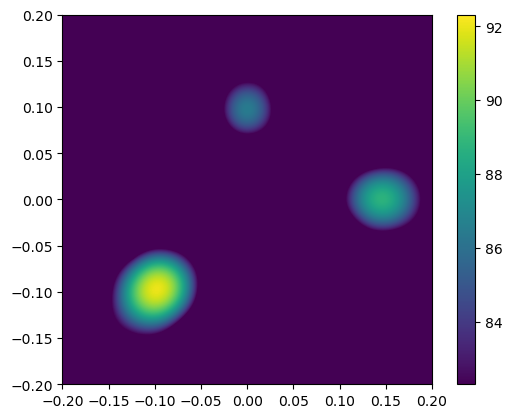

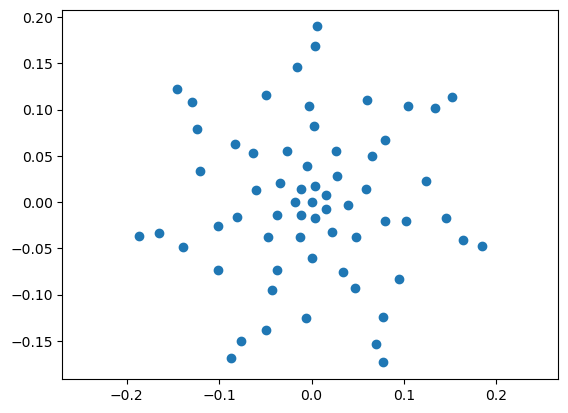

In [1]:
# ------------------------------------------------------------------------------
# Copyright (c) Acoular Development Team.
# ------------------------------------------------------------------------------
"""
Basic Beamforming -- Generate a map of three sources.
=====================================================

Loads the simulated signals from the `three_sources.h5` file, analyzes them with Conventional Beamforming
and generates a map of the three sources.

.. note:: The `three_sources.h5` file must be generated first by running the :doc:`example_three_sources` example.
"""

from pathlib import Path

import acoular as ac
from pylab import axis, colorbar, figure, imshow, plot, show

micgeofile = Path(ac.__file__).parent / 'xml' / 'array_64.xml'
datafile = Path('three_sources.h5')
assert datafile.exists(), 'Data file not found, run example_three_sources.py first'

mg = ac.MicGeom(from_file=micgeofile)
ts = ac.TimeSamples(name=datafile)
ps = ac.PowerSpectra(source=ts, block_size=128, window='Hanning')
rg = ac.RectGrid(x_min=-0.2, x_max=0.2, y_min=-0.2, y_max=0.2, z=0.3, increment=0.01)
st = ac.SteeringVector(grid=rg, mics=mg)
bb = ac.BeamformerBase(freq_data=ps, steer=st)
pm = bb.synthetic(8000, 3)
Lm = ac.L_p(pm)
imshow(Lm.T, origin='lower', vmin=Lm.max() - 10, extent=rg.extend(), interpolation='bicubic')
colorbar()
figure(2)
plot(mg.mpos[0], mg.mpos[1], 'o')
axis('equal')
show()